In [603]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import  train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from pprint import pprint

In [604]:
data = load_digits(as_frame=True, return_X_y=True)
x ,y = data

In [605]:
pprint(load_digits.__doc__)

('Load and return the digits dataset (classification).\n'
 '\n'
 'Each datapoint is an 8x8 image of a digit.\n'
 '\n'
 '=================   ==============\n'
 'Classes                         10\n'
 'Samples per class             ~180\n'
 'Samples total                 1797\n'
 'Dimensionality                  64\n'
 'Features             integers 0-16\n'
 '=================   ==============\n'
 '\n'
 'This is a copy of the test set of the UCI ML hand-written digits datasets\n'
 'https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits\n'
 '\n'
 'Read more in the :ref:`User Guide <digits_dataset>`.\n'
 '\n'
 'Parameters\n'
 '----------\n'
 'n_class : int, default=10\n'
 '    The number of classes to return. Between 0 and 10.\n'
 '\n'
 'return_X_y : bool, default=False\n'
 '    If True, returns ``(data, target)`` instead of a Bunch object.\n'
 '    See below for more information about the `data` and `target` objects.\n'
 '\n'
 '    .. versionadded:: 0.18\n'
 '\n

In [606]:
x.shape

(1797, 64)

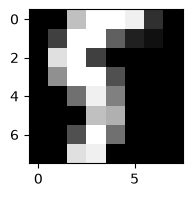

In [607]:
plt.figure(figsize=(2, 2))
i = np.random.randint(0, x.shape[0])
plt.imshow(x.iloc[i].values.reshape(8, 8), 'grey');

In [608]:
x

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [609]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 64 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pixel_0_0  1797 non-null   float64
 1   pixel_0_1  1797 non-null   float64
 2   pixel_0_2  1797 non-null   float64
 3   pixel_0_3  1797 non-null   float64
 4   pixel_0_4  1797 non-null   float64
 5   pixel_0_5  1797 non-null   float64
 6   pixel_0_6  1797 non-null   float64
 7   pixel_0_7  1797 non-null   float64
 8   pixel_1_0  1797 non-null   float64
 9   pixel_1_1  1797 non-null   float64
 10  pixel_1_2  1797 non-null   float64
 11  pixel_1_3  1797 non-null   float64
 12  pixel_1_4  1797 non-null   float64
 13  pixel_1_5  1797 non-null   float64
 14  pixel_1_6  1797 non-null   float64
 15  pixel_1_7  1797 non-null   float64
 16  pixel_2_0  1797 non-null   float64
 17  pixel_2_1  1797 non-null   float64
 18  pixel_2_2  1797 non-null   float64
 19  pixel_2_3  1797 non-null   float64
 20  pixel_2_4  1797 non

In [610]:
(values := y.value_counts())

target
3    183
1    182
5    182
4    181
6    181
9    180
7    179
0    178
2    177
8    174
Name: count, dtype: int64

In [611]:
noise = pd.DataFrame([np.random.randint(0, 17, (64)) for _ in range(180)], columns=x.columns)
x = pd.concat([x, noise], ignore_index=True) 
x

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1972,10.0,3.0,0.0,5.0,15.0,7.0,4.0,14.0,10.0,8.0,...,6.0,13.0,12.0,15.0,2.0,4.0,14.0,3.0,0.0,1.0
1973,16.0,12.0,5.0,2.0,13.0,5.0,9.0,12.0,2.0,10.0,...,14.0,16.0,16.0,11.0,13.0,10.0,6.0,15.0,14.0,4.0
1974,6.0,0.0,9.0,12.0,3.0,5.0,16.0,14.0,5.0,13.0,...,11.0,11.0,4.0,13.0,9.0,5.0,4.0,2.0,10.0,13.0
1975,16.0,5.0,5.0,0.0,11.0,7.0,4.0,2.0,2.0,2.0,...,15.0,8.0,0.0,13.0,1.0,9.0,4.0,1.0,14.0,4.0


In [612]:
invalid = pd.Series([-1 for _ in range(180)])
y = pd.concat([y, invalid], ignore_index=True)
y

0       0
1       1
2       2
3       3
4       4
       ..
1972   -1
1973   -1
1974   -1
1975   -1
1976   -1
Length: 1977, dtype: int64

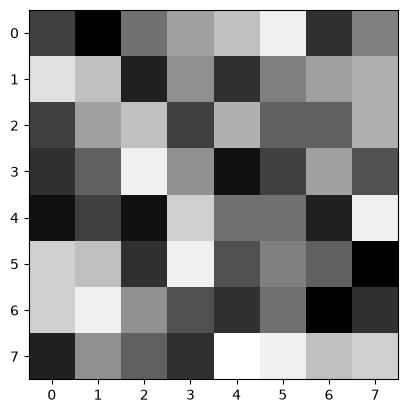

In [613]:
plt.imshow(noise.iloc[0].values.reshape(8,8), cmap='grey');

In [614]:
y.unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, -1])

In [615]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2)
print(xtrain.shape, xtest.shape)

(1581, 64) (396, 64)


In [616]:
model = LogisticRegression(C=0.8, max_iter=500, solver='newton-cg')
model.fit(xtrain, ytrain)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.8
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'newton-cg'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty

In [617]:
print(
    model.score(xtrain,ytrain),
    model.score(xtest, ytest),
    sep='\n'    
    )

1.0
0.9595959595959596


In [618]:
n = np.random.randint(0, 17, (8,8))
model.predict(n.reshape(1, 64))

/home/amin/Projects/Data-Science-excercises/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([-1])

In [619]:
y_pred = model.predict(xtest)
matrix = confusion_matrix(ytest,y_pred)

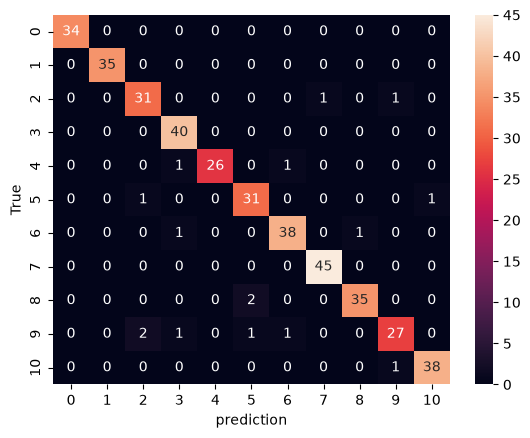

In [620]:
sns.heatmap(matrix, annot=True,)
plt.xlabel('prediction')
plt.ylabel('True');

In [621]:
sample1 = [
    0,  0,  0, 16, 16, 16,  0,  0,
    0,  0,  0,  0,  0, 12,  0,  0,
    0,  0,  0,  0,  0, 12,  0,  0,
    0,  0,  0,  0, 12,  0,  0,  0,
    0,  0,  0,  0, 12,  0,  0,  0,
    0,  0,  0, 12,  0,  0,  0,  0,
    0,  0,  0, 12,  0,  0,  0,  0,
    0,  0,  0,  0,  0,  0,  0,  0
]
sample2 = [
     0,  0,  0, 10,  0,  0,  0,  0,
     0,  0,  0, 12,  0,  0,  0,  0,
     0,  0, 10, 12,  0,  0,  0,  0,
     0, 10,  10, 12,  0,  0,  0,  0,
    10, 10, 10, 16, 16, 16,  0,  0,
     0,  0,  0, 12,  0, 16,  0,  0,
     0,  0,  0, 12,  0, 16,  0,  0,
     0,  0,  0, 12,  0,  0,  0,  0
]
sample3 = [
     0,  0,  8, 12, 12,  8,  0,  0,
     0,  8, 12,  0,  0, 12,  8,  0,
     0,  8, 12,  0,  0, 12,  8,  0,
     0,  0,  8, 12, 12,  8,  0,  0,
     0,  8, 12,  0,  0, 12,  8,  0,
     0,  8, 12,  0,  0, 12,  8,  0,
     0,  8, 12,  0,  0, 12,  8,  0,
     0,  0,  8, 12, 12,  8,  0,  0
]

In [622]:
samples = np.array([sample1, sample2, sample3])
print(model.predict(samples))

[7 6 8]


/home/amin/Projects/Data-Science-excercises/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [623]:
import numpy as np

samples = np.array([sample1, sample2, sample3])

print("Prediction:")
print(model.predict(samples))

print("\nProbabilities:")
pprint(model.predict_proba(samples).round(3))

Prediction:
[7 6 8]

Probabilities:
array([[0.   , 0.   , 0.   , 0.016, 0.011, 0.   , 0.   , 0.   , 0.973,
        0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.469, 0.   , 0.53 , 0.   ,
        0.001, 0.   ],
       [0.008, 0.02 , 0.   , 0.   , 0.026, 0.   , 0.001, 0.001, 0.   ,
        0.941, 0.003]])


/home/amin/Projects/Data-Science-excercises/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/amin/Projects/Data-Science-excercises/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


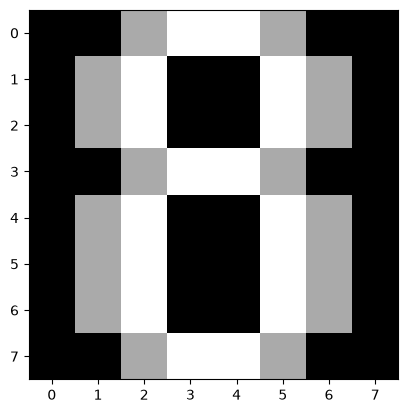

In [624]:
plt.imshow(np.array(sample3).reshape(8,8), cmap='gray');